# **Lecture:** Segment Anything (SAM, Meta AI)

**Objective:** Apply promptable, zero-shot segmentation with SAM through Ultralytics.

SAM does not know class names: it segments *whatever you point at* (a point, a box) or *everything* in the image.

### **Step 1:** Install dependencies

In [1]:
%pip install --upgrade ultralytics opencv-python matplotlib

  Using cached opencv_python-5.0.0.93-cp37-abi3-macosx_13_0_arm64.whl.metadata (19 kB)
INFO: pip is looking at multiple versions of opencv-python to determine which version is compatible with other requirements. This could take a while.
  Using cached opencv_python-4.14.0.94-cp37-abi3-macosx_13_0_arm64.whl.metadata (19 kB)
  Using cached opencv_python-4.13.0.92-cp37-abi3-macosx_13_0_arm64.whl.metadata (19 kB)
  Using cached opencv_python-4.12.0.88-cp37-abi3-macosx_13_0_arm64.whl.metadata (19 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 10.0 MB/s  0:00:00 eta 0:00:01
  Attempting uninstall: ultralytics
    Found existing installation: ultralytics 8.4.172
    Uninstalling ultralytics-8.4.172:
      Successfully uninstalled ultralytics-8.4.172
Note: you may need to restart the kernel to use updated packages.


### **Step 2:** Load and show an image

(-0.5, 809.5, 1079.5, -0.5)

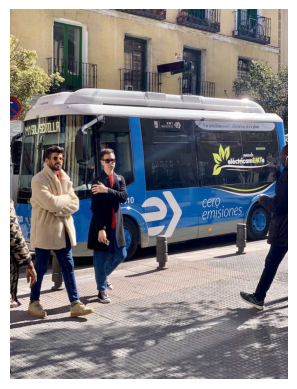

In [2]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread('bus.jpg')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img)
plt.axis('off')

### **Step 3:** Load SAM and segment everything

With no prompt, SAM generates a mask for every region it finds. `mobile_sam.pt` (≈39 MB) is downloaded automatically on first use. This takes several seconds on CPU.

AM was trained by Meta on the monumental SA-1B Dataset containing over 1 billion masks across 11 million images. 

This image showcases the exact behavior of "SAM Everything" mode (automatic mask generation). Because SAM has no concept of labels or human anatomy, it breaks the scene down purely by geometry:

Masks found: 82


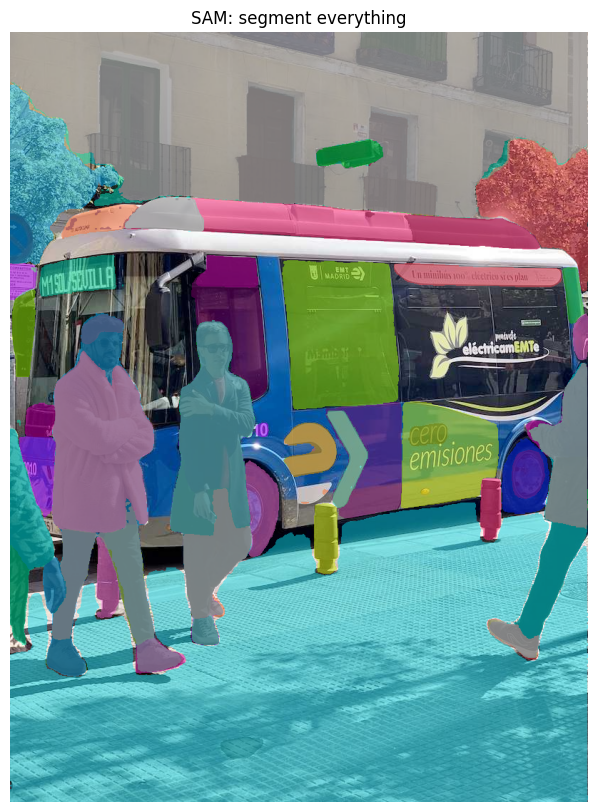

In [3]:
from ultralytics import SAM

model = SAM('mobile_sam.pt')

result = model('bus.jpg', verbose=False)[0]  # no prompt = segment everything
print(f'Masks found: {len(result.masks)}')

plt.figure(figsize=(8, 10))
plt.imshow(cv2.cvtColor(result.plot(boxes=False, labels=False), cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title('SAM: segment everything')
plt.show()

### **Step 4:** Prompt with a point

Give SAM one (x, y) pixel with label `1` (foreground) and it segments only the object under it. Change the coordinates to select a different object (the image is 810x1080).

Mask area: 31768 px


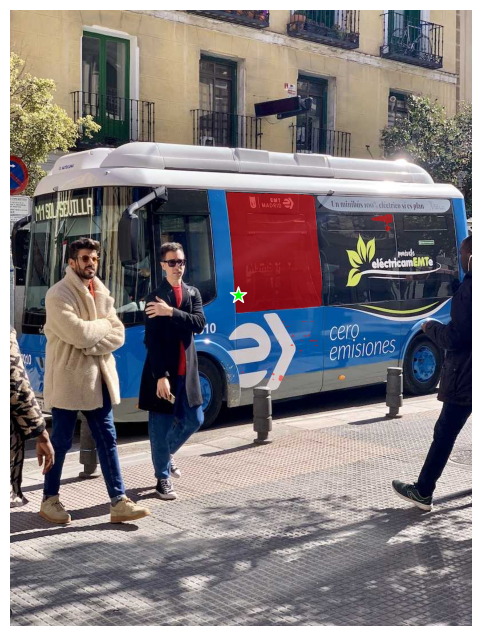

In [4]:
import numpy as np

def show_mask(image_rgb, mask, point=None, box=None):
    overlay = image_rgb.copy()
    overlay[mask] = (0.5 * overlay[mask] + 0.5 * np.array([255, 0, 0])).astype(np.uint8)
    plt.figure(figsize=(6, 8))
    plt.imshow(overlay)
    if point is not None:
        plt.scatter(*point, c='lime', s=150, marker='*', edgecolors='white')
    if box is not None:
        x1, y1, x2, y2 = box
        plt.gca().add_patch(plt.Rectangle((x1, y1), x2 - x1, y2 - y1, fill=False, edgecolor='cyan', linewidth=2))
    plt.axis('off')
    plt.show()

point = [400, 500]  # (x, y) on the bus
result = model('bus.jpg', points=[point], labels=[1], verbose=False)[0]
mask = result.masks.data[0].cpu().numpy().astype(bool)
print(f'Mask area: {mask.sum()} px')
show_mask(img, mask, point=point)

### **Step 5:** Prompt with a bounding box

A box `[x1, y1, x2, y2]` is another prompt. Here we segment the person on the left.

Mask area: 46733 px


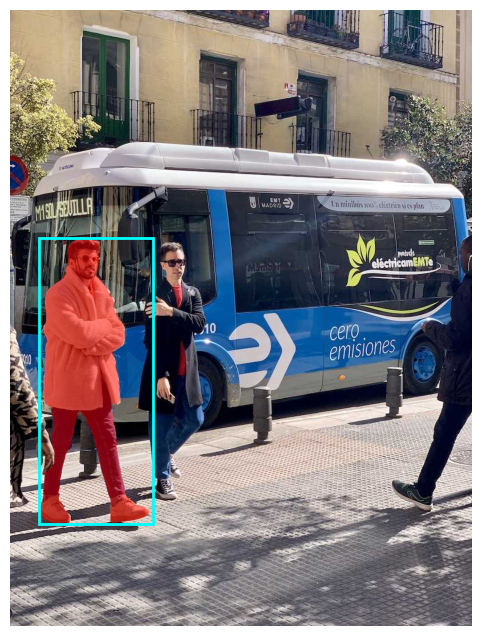

In [5]:
box = [50, 400, 250, 900]
result = model('bus.jpg', bboxes=box, verbose=False)[0]
mask = result.masks.data[0].cpu().numpy().astype(bool)
print(f'Mask area: {mask.sum()} px')
show_mask(img, mask, box=box)

### **Individual Activity**
- Try your own image and click-equivalent points (use several points, or a point with label `0` to exclude a region).
- Combine YOLO + SAM: use a YOLO detection box as the SAM box prompt to obtain a precise mask per detected object.

## Questions
1. Difference: bounding box vs mask
2. Why SAM is zero-shot?
3. When use Detectron2?
